<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/ESTE_SI_O_SI_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 2: Preparación de Datos y Modelos de Regresión

**Autores:** Juan Mora, Benjamin Camus, Jose Paillan  
**Correos:** jua.morar@duocuc.cl  
**Fecha de creación:** Mayo 2026  
**Versión:** 1.0

---

## Descripción

Este notebook corresponde a la Fase 2 del proyecto semestral de Minería de Datos (BIY7121). Se aplican las fases 3 y 4 de la metodología CRISP-DM: preparación de datos y modelamiento, sobre un conjunto de datos climáticos históricos de Chile del año 2025.

El caso de estudio es una empresa agrícola cuya producción depende directamente de las condiciones climáticas. Predecir la temperatura permite anticipar heladas, planificar riegos y optimizar la cosecha. La variable objetivo es `temperature_2m`.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)
- seaborn (0.13.1)
- scikit-learn (1.6.0)

## Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

RANDOM_STATE = 29

In [ ]:
url = "https://raw.githubusercontent.com/juanpablomora36/mineria-datos-clima/main/data_clima_2025_final.csv"
data = pd.read_csv(url)
data['date'] = pd.to_datetime(data['date'], utc=True)
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


In [ ]:
data.shape

(33024, 15)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   date                  33024 non-null  datetime64[ns, UTC]
 1   temperature_2m        33024 non-null  float64            
 2   relative_humidity_2m  33024 non-null  float64            
 3   apparent_temperature  33024 non-null  float64            
 4   precipitation         33024 non-null  float64            
 5   cloud_cover           33024 non-null  float64            
 6   wind_speed_10m        33024 non-null  float64            
 7   wind_direction_10m    33024 non-null  float64            
 8   rain                  33024 non-null  float64            
 9   is_day                33024 non-null  float64            
 10  sunshine_duration     33024 non-null  float64            
 11  Localidad             33024 non-null  object             
 12  lati

In [ ]:
data.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,latitud,longitud,is_rainy_hour
count,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000
mean,10.644075,79.042842,8.337603,0.138981,62.114977,11.930189,205.227225,0.136601,0.495882,1221.216663,-42.134914,-72.448638,0.184714
std,5.213359,16.228987,6.350746,0.582210,41.871036,8.474665,101.410042,0.577866,0.499991,1650.360797,6.456137,0.920869,0.388071
min,-5.100000,15.230701,-8.741941,0.000000,0.000000,0.000000,0.367278,0.000000,0.000000,0.000000,-53.162569,-73.245986,0.000000
25%,7.050000,68.349886,3.876656,0.000000,13.000000,5.649248,139.531913,0.000000,0.000000,0.000000,-43.151237,-73.099151,0.000000
50%,10.400000,82.217838,8.232820,0.000000,88.000000,9.940824,229.398790,0.000000,0.000000,0.000000,-39.275008,-72.820372,0.000000
75%,13.700000,92.891105,12.350445,0.000000,100.000000,15.882896,284.036250,0.000000,1.000000,3600.000000,-38.258686,-72.169859,0.000000
max,31.750000,100.000000,32.108310,13.200000,100.000000,65.250920,360.000000,13.200000,1.000000,3600.000000,-36.827070,-70.907822,1.000000


**Descripción del dataset:** El conjunto de datos cuenta con 33.024 registros y 15 columnas. La columna `date` fue convertida a formato datetime para extraer variables temporales. Las columnas numéricas son de tipo `float64` o `int64`. La columna `Localidad` es de tipo texto y será codificada mediante `OneHotEncoder`.

---
# Fase 2 – Entendimiento de los Datos

## 1. Identificación de Valores Duplicados

Se revisa la existencia de registros duplicados en el conjunto de datos, es decir, filas que presenten exactamente los mismos valores en todas sus columnas.

In [ ]:
duplicados = data[data.duplicated()]
print(f'Cantidad de registros duplicados: {len(duplicados)}')
duplicados

Cantidad de registros duplicados: 0


,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour


**Hallazgo:** No se identificaron registros duplicados en el conjunto de datos. Cada observación corresponde a una medición horaria única por localidad, lo cual es consistente con la naturaleza de los datos provenientes de estaciones meteorológicas. Al no existir duplicados, no se requiere aplicar ningún tratamiento en esta dimensión. De existir duplicados en el futuro, la acción correcta sería eliminarlos mediante `drop_duplicates()` para evitar que el modelo aprenda patrones artificialmente repetidos.

## 2. Identificación de Valores Nulos

Se analiza la presencia de valores faltantes en cada variable del conjunto de datos, incluyendo el porcentaje que representan sobre el total de registros.

In [ ]:
nulos = data.isna().sum().rename('Cantidad de nulos')
nulos_pct = (nulos / len(data) * 100).rename('% de nulos')
pd.concat([nulos, nulos_pct], axis=1)

,Cantidad de nulos,% de nulos
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
cloud_cover,0,0.0
wind_speed_10m,0,0.0
wind_direction_10m,0,0.0
rain,0,0.0
is_day,0,0.0


**Hallazgo:** No se identificaron valores nulos en ninguna de las variables del conjunto de datos. El dataset se encuentra completamente íntegro con 33.024 registros válidos en todas sus columnas. Al no existir valores faltantes, no se requiere aplicar técnicas de imputación en esta etapa. No obstante, el pipeline ha sido configurado con un `SimpleImputer` como buena práctica, considerando que datos futuros podrían presentar esta situación.

## 3. Identificación de Valores Atípicos

Se identifican valores extremos en las variables numéricas mediante el método del rango intercuartílico (IQR). Este método define como atípicos aquellos valores que se encuentran fuera del intervalo `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`.

In [ ]:
def buscar_atipicos(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]

columnas_atipicos = [
    'temperature_2m', 'relative_humidity_2m', 'precipitation',
    'cloud_cover', 'wind_speed_10m', 'wind_direction_10m',
    'rain', 'sunshine_duration'
]

atipicos = {col: len(buscar_atipicos(data, col)) for col in columnas_atipicos}
pd.DataFrame.from_dict(atipicos, orient='index', columns=['Cantidad Atípicos'])

,Cantidad Atípicos
temperature_2m,476
relative_humidity_2m,130
precipitation,6152
cloud_cover,0
wind_speed_10m,1241
wind_direction_10m,0
rain,6100
sunshine_duration,0


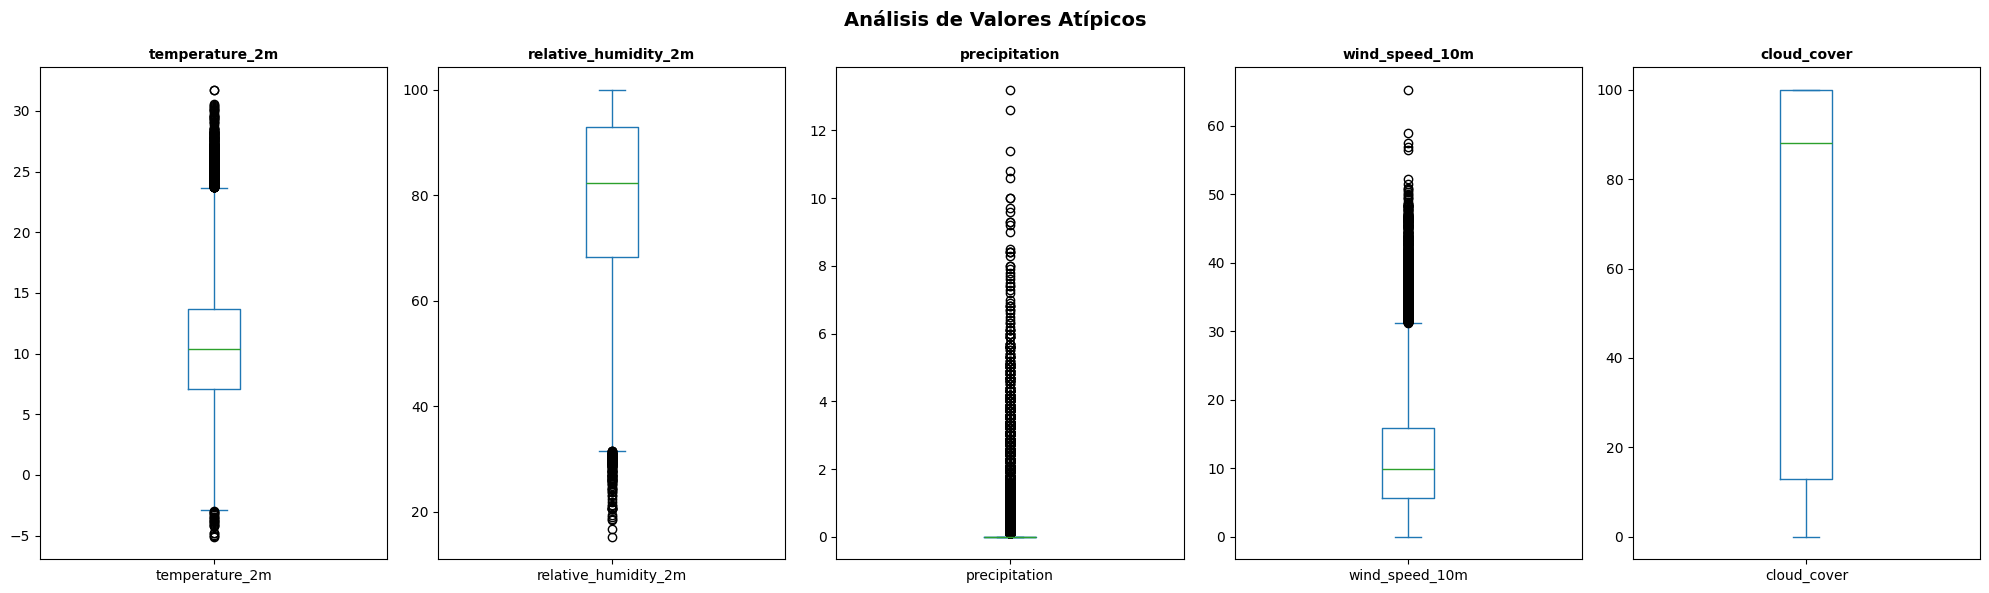

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for i, col in enumerate(['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'cloud_cover']):
    data[col].plot(kind='box', ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
plt.suptitle('Análisis de Valores Atípicos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Hallazgo:** Se identificaron valores atípicos en las variables `temperature_2m`, `precipitation`, `wind_speed_10m` y `rain`. Estos valores no representan errores, sino eventos climáticos reales como heladas, olas de calor y ráfagas de viento intensas. Como tratamiento, se aplica **Winsorización** dentro del pipeline (percentiles 0.1%-99.9%), reduciendo el impacto de los extremos sin eliminar información válida.

## 4. Identificación de Inconsistencias

Se verifica que los valores de las variables se encuentren dentro de rangos lógicos según el dominio del problema.

In [ ]:
for columna in ['relative_humidity_2m', 'precipitation', 'cloud_cover',
                'wind_speed_10m', 'wind_direction_10m', 'rain',
                'is_day', 'sunshine_duration', 'is_rainy_hour']:
    print(f"{columna:<25} tiene {len(data[data[columna] < 0])} valores negativos")

print()
print("Humedad fuera de rango [0,100]:",
      len(data[(data['relative_humidity_2m'] < 0) | (data['relative_humidity_2m'] > 100)]))
print("Dirección del viento fuera de rango [0,360]:",
      len(data[(data['wind_direction_10m'] < 0) | (data['wind_direction_10m'] > 360)]))
print("Nubosidad fuera de rango [0,100]:",
      len(data[(data['cloud_cover'] < 0) | (data['cloud_cover'] > 100)]))

relative_humidity_2m      tiene 0 valores negativos
precipitation             tiene 0 valores negativos
cloud_cover               tiene 0 valores negativos
wind_speed_10m            tiene 0 valores negativos
wind_direction_10m        tiene 0 valores negativos
rain                      tiene 0 valores negativos
is_day                    tiene 0 valores negativos
sunshine_duration         tiene 0 valores negativos
is_rainy_hour             tiene 0 valores negativos

Humedad fuera de rango [0,100]: 0
Dirección del viento fuera de rango [0,360]: 0
Nubosidad fuera de rango [0,100]: 0


**Hallazgo:** No se identificaron inconsistencias en el conjunto de datos. Todas las variables se encuentran dentro de rangos físicamente posibles. El dataset proviene de una fuente confiable (open-meteo.com) con preprocesamiento previo, lo que explica la ausencia de este tipo de problemas. De existir inconsistencias, la acción correcta sería eliminar esos registros ya que representarían errores de medición sin posibilidad de corrección.

---
# Fase 3 – Preparación de Datos

## 5. Extracción de Variables Temporales: Hora y Mes

A partir de la columna `date` se extraen las variables `hora` y `mes`, necesarias para las transformaciones cíclicas.

In [ ]:
data['fecha'] = pd.to_datetime(data['date'])
data['hora']  = data['fecha'].dt.hour
data['mes']   = data['fecha'].dt.month

print('Horas únicas:', sorted(data['hora'].unique()))
print('Meses únicos:', sorted(data['mes'].unique()))

Horas únicas: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
Meses únicos: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


**Hallazgo:** Se extrajeron correctamente las variables `hora` (0 a 23) y `mes` (1 a 12) desde la columna `date`. Estas variables serán transformadas mediante funciones trigonométricas para preservar su naturaleza cíclica.

## 6. Transformación Cíclica de Hora y Mes

Las variables temporales son **cíclicas**: la hora 23 y la hora 0 son adyacentes, al igual que diciembre y enero. La solución es proyectarlas sobre un círculo usando seno y coseno:

- `hora_sin = sin(2π × hora / 24)` y `hora_cos = cos(2π × hora / 24)`
- `mes_sin  = sin(2π × mes / 12)` y `mes_cos  = cos(2π × mes / 12)`

In [ ]:
data['hora_sin'] = np.sin(2 * np.pi * data['hora'] / 24)
data['hora_cos'] = np.cos(2 * np.pi * data['hora'] / 24)
data['mes_sin']  = np.sin(2 * np.pi * data['mes']  / 12)
data['mes_cos']  = np.cos(2 * np.pi * data['mes']  / 12)

data[['hora', 'hora_sin', 'hora_cos', 'mes', 'mes_sin', 'mes_cos']].head(10)

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
0,3,7.071068e-01,7.071068e-01,1,0.5,0.866025
1,4,8.660254e-01,5.000000e-01,1,0.5,0.866025
2,5,9.659258e-01,2.588190e-01,1,0.5,0.866025
3,6,1.000000e+00,6.123234e-17,1,0.5,0.866025
4,7,9.659258e-01,-2.588190e-01,1,0.5,0.866025
5,8,8.660254e-01,-5.000000e-01,1,0.5,0.866025
6,9,7.071068e-01,-7.071068e-01,1,0.5,0.866025
7,10,5.000000e-01,-8.660254e-01,1,0.5,0.866025
8,11,2.588190e-01,-9.659258e-01,1,0.5,0.866025
9,12,1.224647e-16,-1.000000e+00,1,0.5,0.866025


**Resultado:** Se generaron 4 nuevas variables cíclicas. Cada par (sin/cos) representa una variable temporal como un punto en un círculo, permitiendo al modelo entender que la hora 23 y la hora 0 son vecinas, y que diciembre y enero pertenecen al mismo ciclo estacional.

## 7. Transformación de Variables Binarias a Categóricas

Las variables `is_day` e `is_rainy_hour` son variables binarias que representan condiciones del momento actual. Se transforman a texto descriptivo para tratarlas como variables cualitativas dentro del pipeline.

In [ ]:
data['is_rainy_hour'] = data['is_rainy_hour'].map({0: 'No llueve', 1: 'Llueve'})
data['is_day']        = data['is_day'].map({0: 'Noche', 1: 'Día'})

print(data['is_rainy_hour'].value_counts())
print()
print(data['is_day'].value_counts())

is_rainy_hour
No llueve    26924
Llueve        6100
Name: count, dtype: int64

is_day
Noche    16648
Día      16376
Name: count, dtype: int64


**Resultado:** Las variables `is_day` e `is_rainy_hour` fueron transformadas a categorías descriptivas. Esto permite tratarlas como variables cualitativas dentro del pipeline y aplicarles codificación mediante `OneHotEncoder`.

## 8. Ventanas de Tiempo (Lags)

El tiempo tiene **memoria**: la temperatura actual depende de la temperatura de las horas anteriores (inercia térmica). Para capturar esta dependencia se crean variables rezagadas por localidad.

**Decisión del equipo: lags sectorizados por localidad.** Cada ciudad tiene un clima distinto, por lo que mezclar los datos de Punta Arenas con Concepción introduciría información incorrecta al modelo.

In [ ]:
data = data.sort_values(['Localidad', 'fecha']).copy()

# Lags de temperatura
data['temp_lag_1h']  = data.groupby('Localidad')['temperature_2m'].shift(1)
data['temp_lag_2h']  = data.groupby('Localidad')['temperature_2m'].shift(2)
data['temp_lag_3h']  = data.groupby('Localidad')['temperature_2m'].shift(3)
data['temp_lag_12h'] = data.groupby('Localidad')['temperature_2m'].shift(12)
data['temp_lag_24h'] = data.groupby('Localidad')['temperature_2m'].shift(24)

# Tendencias de temperatura
data['temp_tendencia_1h']  = data['temp_lag_1h'] - data['temp_lag_2h']
data['temp_tendencia_24h'] = data['temp_lag_1h'] - data.groupby('Localidad')['temperature_2m'].shift(25)

# Lags de variables climáticas auxiliares
data['humedad_lag_1h']   = data.groupby('Localidad')['relative_humidity_2m'].shift(1)
data['humedad_lag_24h']  = data.groupby('Localidad')['relative_humidity_2m'].shift(24)
data['apparent_lag_1h']  = data.groupby('Localidad')['apparent_temperature'].shift(1)
data['apparent_lag_24h'] = data.groupby('Localidad')['apparent_temperature'].shift(24)
data['nubes_lag_1h']     = data.groupby('Localidad')['cloud_cover'].shift(1)
data['sunshine_lag_1h']  = data.groupby('Localidad')['sunshine_duration'].shift(1)

print('Nulos generados por lags:')
print(data[['temp_lag_1h','temp_lag_12h','temp_lag_24h','humedad_lag_24h','apparent_lag_24h']].isna().sum())

Nulos generados por lags:
temp_lag_1h          4
temp_lag_12h        48
temp_lag_24h        96
humedad_lag_24h     96
apparent_lag_24h    96
dtype: int64


In [ ]:
# Ventanas móviles
data['temp_rolling_3h'] = (
    data.groupby('Localidad')['temperature_2m']
    .shift(1).rolling(3).mean()
    .reset_index(0, drop=True)
)
data['temp_rolling_6h'] = (
    data.groupby('Localidad')['temperature_2m']
    .shift(1).rolling(6).mean()
    .reset_index(0, drop=True)
)
data['temp_rolling_24h'] = (
    data.groupby('Localidad')['temperature_2m']
    .shift(1).rolling(24).mean()
    .reset_index(0, drop=True)
)
data['humidity_rolling_3h'] = (
    data.groupby('Localidad')['relative_humidity_2m']
    .shift(1).rolling(3).mean()
    .reset_index(0, drop=True)
)
data['humidity_rolling_12h'] = (
    data.groupby('Localidad')['relative_humidity_2m']
    .shift(1).rolling(12).mean()
    .reset_index(0, drop=True)
)
data['wind_rolling_12h'] = (
    data.groupby('Localidad')['wind_speed_10m']
    .shift(1).rolling(12).mean()
    .reset_index(0, drop=True)
)
data['lluvia_rolling_24h'] = (
    data.groupby('Localidad')['precipitation']
    .shift(1).rolling(24).sum()
    .reset_index(0, drop=True)
)

print('Nulos tras ventanas móviles:')
print(data[['temp_rolling_24h','humidity_rolling_12h','wind_rolling_12h','lluvia_rolling_24h']].isna().sum())

Nulos tras ventanas móviles:
temp_rolling_24h        96
humidity_rolling_12h    48
wind_rolling_12h        48
lluvia_rolling_24h      96
dtype: int64


In [ ]:
data = data.dropna().copy()
print('Filas tras eliminar nulos:', len(data))

Filas tras eliminar nulos: 32924


**Resultado:** Se generaron variables de rezago y ventanas móviles para incorporar información histórica al modelo. Los nulos generados corresponden a las primeras filas de cada localidad donde no existe historial previo. Para evitar fuga de información, las ventanas móviles fueron construidas con `shift(1)`, por lo que cada registro solo utiliza información disponible antes del momento de predicción.

## 9. Evaluación de Variables Predictoras

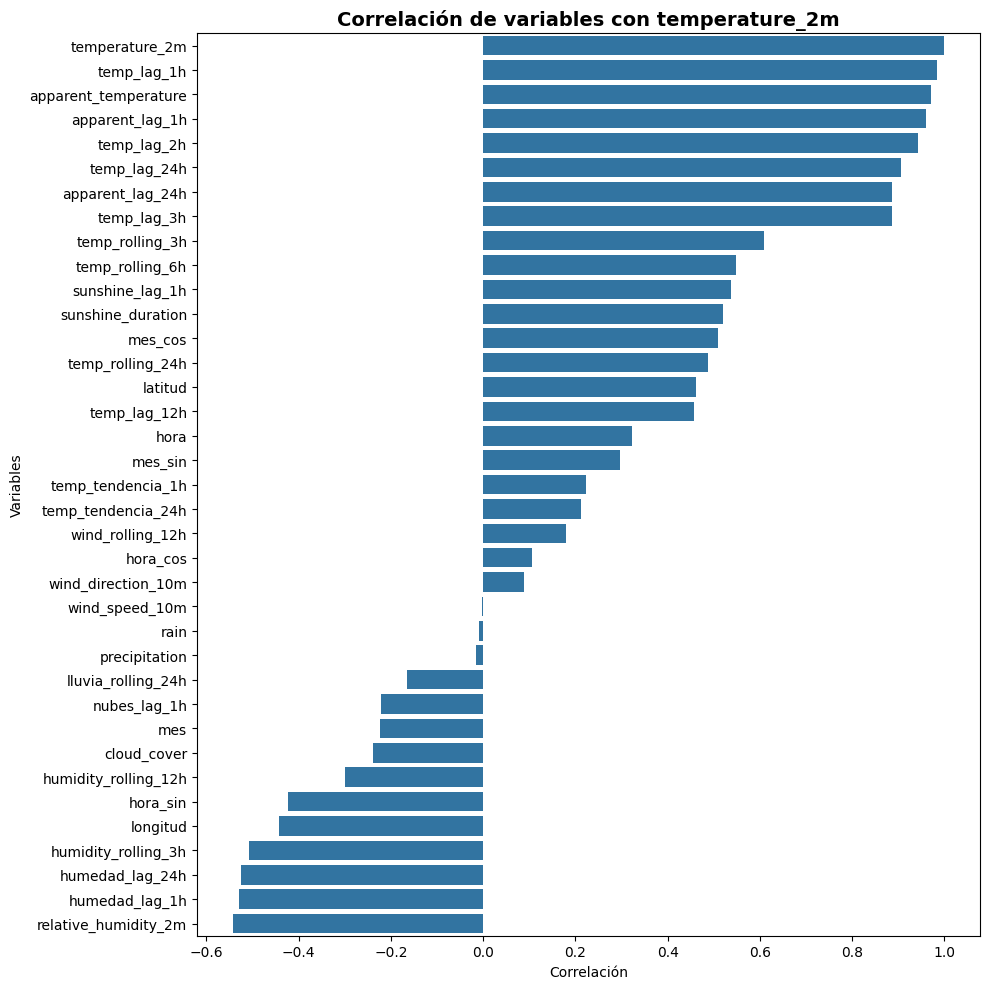

In [ ]:
correlaciones = data.corr(numeric_only=True)
correlacion_objetivo = correlaciones['temperature_2m'].sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=correlacion_objetivo.values, y=correlacion_objetivo.index)
plt.title('Correlación de variables con temperature_2m', fontsize=14, fontweight='bold')
plt.xlabel('Correlación')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

**Interpretación:** Se calculó la correlación de las variables numéricas con la variable objetivo `temperature_2m`. Las variables de rezago de temperatura y sensación térmica presentan alta relación con la temperatura actual, lo que confirma su relevancia predictiva. La selección final de variables considera tanto la correlación como el criterio de funcionalidad del modelo.

## 10. Definición de Variables y División del Dataset

In [ ]:
TARGET = 'temperature_2m'

features_num = [
    # Variables climáticas del momento actual
    'relative_humidity_2m',
    'precipitation',
    'cloud_cover',
    'wind_speed_10m',
    'wind_direction_10m',
    'rain',
    'sunshine_duration',
    # Variables geográficas
    'latitud',
    'longitud',
    # Transformaciones cíclicas
    'hora_sin', 'hora_cos',
    'mes_sin',  'mes_cos',
    # Lags de temperatura
    'temp_lag_1h', 'temp_lag_12h', 'temp_lag_24h',
    'temp_tendencia_1h', 'temp_tendencia_24h',
    # Ventanas móviles de temperatura
    'temp_rolling_3h', 'temp_rolling_6h', 'temp_rolling_24h',
    # Lags de humedad y ventanas
    'humedad_lag_1h', 'humedad_lag_24h',
    'humidity_rolling_3h', 'humidity_rolling_12h',
    # Lags de temperatura aparente
    'apparent_lag_1h', 'apparent_lag_24h',
    # Otras variables históricas
    'nubes_lag_1h', 'sunshine_lag_1h',
    'wind_rolling_12h', 'lluvia_rolling_24h'
]

features_cat = [
    'Localidad',
    'is_day',
    'is_rainy_hour'
]

X = data[features_num + features_cat]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (26339, 34)
X_test:  (6585, 34)


**Interpretación:** Se definió `temperature_2m` como variable objetivo. Las variables predictoras incluyen información climática del momento actual, variables geográficas, transformaciones temporales cíclicas y variables históricas generadas mediante rezagos y ventanas móviles. La variable `apparent_temperature` no se usa en su valor actual por su alta correlación con el objetivo, sino solo sus rezagos.

## 11. Construcción del Pipeline

Se definen las clases personalizadas y se construye el pipeline de preprocesamiento.

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Tratamiento de atípicos mediante recorte por percentiles."""
    def __init__(self, limits=(0.001, 0.001)):
        self.limits = limits

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lower, upper)
        return X.values

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        return np.array(input_features)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Eliminación de variables con correlación superior al umbral."""
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.columns_to_drop_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.columns_to_drop_ = [
            col for col in upper.columns if any(upper[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.columns_to_drop_, errors='ignore').values


print('Clases definidas correctamente')

Clases definidas correctamente


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('winsorizer', Winsorizer(limits=(0.001, 0.001))),
    ('imputer',    SimpleImputer(strategy='mean')),
    ('scaler',     StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('winsorizer', Winsorizer()),
                                                 ('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['relative_humidity_2m', 'precipitation',
                                  'cloud_cover', 'wind_speed_10m',
                                  'wind_direction_10m', 'rain',
                                  'sunshine_duration', 'latitud', 'longitud',
                                  'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
                                  'temp_lag_1h', 'temp_lag_12h...
                                  'temp_rolling_24h', 'humedad_lag_1h',
                                  'humedad_lag_24h', 'humidity_rolling_3h',
                                  'humidity_rolling_12h', 'apparent_lag_1h',
                                  'apparent_lag_24h', 'nubes_lag_1h',
                                  'sunshine_lag_1h', 'wind_rolling_12h', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Localidad', 'is_day', 'is_rainy_hour'])])

**Descripción del pipeline:**

- **Variables numéricas:** Winsorización (percentil 0.1%-99.9%) → Imputación con media → Estandarización con `StandardScaler`.
- **Variables categóricas:** Imputación con moda → `OneHotEncoder`.
- **CorrelationFilter:** se aplica al modelo de regresión lineal para eliminar variables con correlación > 0.9 y reducir problemas de multicolinealidad.

## 12. Dataset Preparado

In [ ]:
print(f'Dimensiones del dataset preparado: {data[features_num + features_cat + [TARGET]].shape}')
data[features_num + features_cat + [TARGET]].head(10)

Dimensiones del dataset preparado: (32924, 35)


,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,sunshine_duration,latitud,longitud,hora_sin,...,apparent_lag_1h,apparent_lag_24h,nubes_lag_1h,sunshine_lag_1h,wind_rolling_12h,lluvia_rolling_24h,Localidad,is_day,is_rainy_hour,temperature_2m
25,67.133560,0.0,0.0,11.367109,190.95403,0.0,0.0000,-36.82707,-73.050206,8.660254e-01,...,15.285278,12.787600,0.0,0.0000,16.479034,0.0,"Concepción, Chile",Noche,No llueve,16.10
26,70.217310,0.0,0.0,9.957109,192.52880,0.0,0.0000,-36.82707,-73.050206,9.659258e-01,...,14.457993,12.131762,0.0,0.0000,16.448413,0.0,"Concepción, Chile",Noche,No llueve,15.45
27,72.034836,0.0,0.0,10.132897,192.30800,0.0,0.0000,-36.82707,-73.050206,1.000000e+00,...,14.028061,11.714258,0.0,0.0000,16.016744,0.0,"Concepción, Chile",Noche,No llueve,15.00
28,77.145110,0.0,0.0,9.144637,190.20392,0.0,0.0000,-36.82707,-73.050206,9.659258e-01,...,13.538231,11.426943,0.0,0.0000,15.424124,0.0,"Concepción, Chile",Noche,No llueve,14.30
29,82.352180,0.0,0.0,5.626259,172.64772,0.0,0.0000,-36.82707,-73.050206,8.660254e-01,...,13.083412,11.337353,0.0,0.0000,14.663179,0.0,"Concepción, Chile",Noche,No llueve,13.55
30,80.072815,0.0,0.0,4.765752,169.11452,0.0,0.0000,-36.82707,-73.050206,7.071068e-01,...,12.920006,11.573025,0.0,0.0000,13.495177,0.0,"Concepción, Chile",Noche,No llueve,12.75
31,77.191826,0.0,0.0,6.185822,188.36580,0.0,0.0000,-36.82707,-73.050206,5.000000e-01,...,11.903036,11.725235,0.0,0.0000,12.174053,0.0,"Concepción, Chile",Día,No llueve,12.95
32,72.887200,0.0,0.0,7.256032,187.12492,0.0,3214.7847,-36.82707,-73.050206,2.588190e-01,...,11.800503,13.212156,0.0,0.0000,11.041380,0.0,"Concepción, Chile",Día,No llueve,14.35
33,58.513603,0.0,0.0,5.785257,185.35573,0.0,3600.0000,-36.82707,-73.050206,1.224647e-16,...,13.181156,14.641125,0.0,3214.7847,10.046948,0.0,"Concepción, Chile",Día,No llueve,16.30
34,51.618908,0.0,0.0,5.959060,205.01686,0.0,3600.0000,-36.82707,-73.050206,-2.588190e-01,...,14.971949,15.634848,0.0,3600.0000,9.086789,0.0,"Concepción, Chile",Día,No llueve,18.50


## 13. Guardar Dataset en CSV

In [ ]:
data.to_csv('data_modelo_GX.csv', index=False)
print('Archivo guardado: data_modelo_GX.csv')

Archivo guardado: data_modelo_GX.csv


---
# Fase 4 – Modelamiento

## 14. Definición de Pipelines de Modelamiento

In [ ]:
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('colinealidad',     CorrelationFilter(threshold=0.9)),
    ('modelo',           LinearRegression())
])

pipeline_dtr = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo',           DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=15,
        min_samples_leaf=7,
        random_state=RANDOM_STATE
    ))
])

In [ ]:
pipeline_lr

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'precipitation',
                                                   'cloud_cover',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m', 'rain',
                                                   'sunshine_duration',
                                                   'latitud', 'longitud',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', '...
                                                   'humidity_rolling_12h',
                                                   'apparent_lag_1h',
                                                   'apparent_lag_24h',
                                                   'nubes_lag_1h',
                                                   'sunshine_lag_1h',
                                                   'wind_rolling_12h', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

In [ ]:
pipeline_dtr

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_humidity_2m',
                                                   'precipitation',
                                                   'cloud_cover',
                                                   'wind_speed_10m',
                                                   'wind_direction_10m', 'rain',
                                                   'sunshine_duration',
                                                   'latitud', 'longitud',
                                                   'hora_sin', 'hora_cos',
                                                   'mes_sin', '...
                                                   'apparent_lag_24h',
                                                   'nubes_lag_1h',
                                                   'sunshine_lag_1h',
                                                   'wind_rolling_12h', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Localidad', 'is_day',
                                                   'is_rainy_hour'])])),
                ('modelo',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=7,
                                       min_samples_split=15,
                                       random_state=29))])

**Descripción:** Se construyeron dos pipelines de modelamiento. La regresión lineal incorpora un filtro de colinealidad para reducir variables altamente correlacionadas. El árbol de decisión captura relaciones no lineales entre las variables.

## 15. Entrenamiento de los Modelos

In [ ]:
pipeline_lr.fit(X_train, y_train)
pipeline_dtr.fit(X_train, y_train)
print('Modelos entrenados correctamente')

Modelos entrenados correctamente


## 16. Evaluación de los Modelos

In [ ]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)
    return {
        'Modelo':     nombre,
        'R2 Train':   r2_score(y_train, pred_train),
        'R2 Test':    r2_score(y_test,  pred_test),
        'MAE Train':  mean_absolute_error(y_train, pred_train),
        'MAE Test':   mean_absolute_error(y_test,  pred_test)
    }

resultados = [
    evaluar_modelo('LinearRegression',      pipeline_lr,  X_train, y_train, X_test, y_test),
    evaluar_modelo('DecisionTreeRegressor', pipeline_dtr, X_train, y_train, X_test, y_test)
]

tabla = pd.DataFrame(resultados)
tabla['Diferencia R2']  = abs(tabla['R2 Train']  - tabla['R2 Test'])
tabla['Condición'] = np.where(
    tabla['Diferencia R2'] > 0.05,
    'Posible Overfitting',
    'Sin overfitting'
)
tabla.round(4)

,Modelo,R2 Train,R2 Test,MAE Train,MAE Test,Diferencia R2,Condición
0,LinearRegression,0.9906,0.9905,0.3715,0.3714,0.0001,Sin overfitting
1,DecisionTreeRegressor,0.9919,0.9860,0.3489,0.4420,0.0060,Sin overfitting


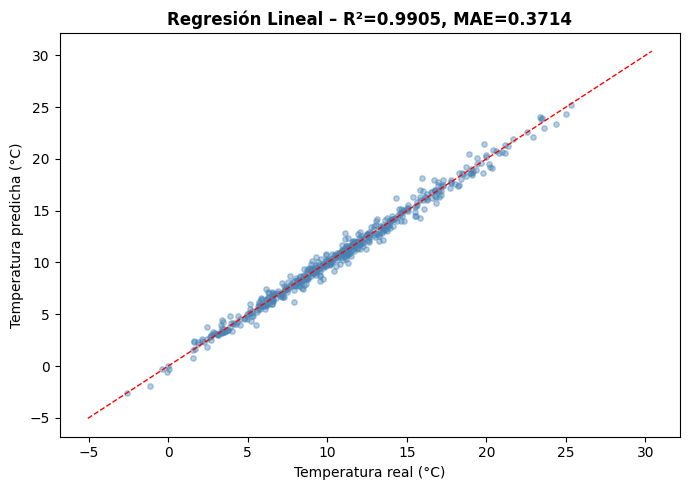

In [ ]:
# Gráfico predicciones vs reales — Regresión Lineal
y_pred_lr = pipeline_lr.predict(X_test)
idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=500, replace=False)
lims = [float(y_test.min()), float(y_test.max())]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test.iloc[idx], y_pred_lr[idx], alpha=0.4, s=15, color='steelblue')
ax.plot(lims, lims, '--r', linewidth=1)
ax.set_xlabel('Temperatura real (°C)')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title(
    f'Regresión Lineal – R²={r2_score(y_test, y_pred_lr):.4f}, MAE={mean_absolute_error(y_test, y_pred_lr):.4f}',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

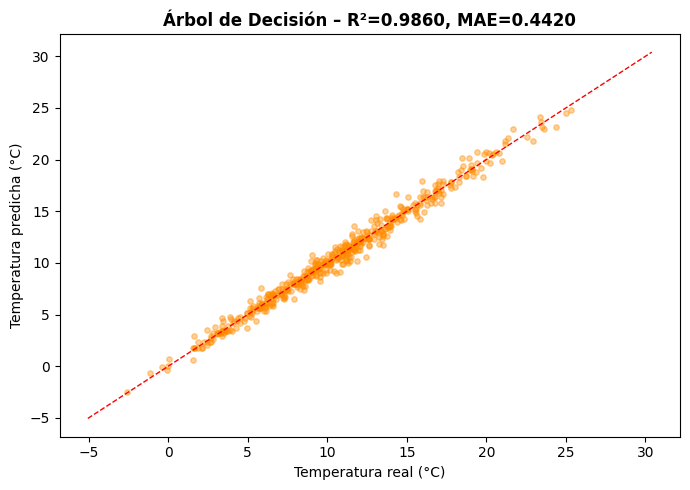

In [ ]:
# Gráfico predicciones vs reales — Árbol de Decisión
y_pred_dtr = pipeline_dtr.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test.iloc[idx], y_pred_dtr[idx], alpha=0.4, s=15, color='darkorange')
ax.plot(lims, lims, '--r', linewidth=1)
ax.set_xlabel('Temperatura real (°C)')
ax.set_ylabel('Temperatura predicha (°C)')
ax.set_title(
    f'Árbol de Decisión – R²={r2_score(y_test, y_pred_dtr):.4f}, MAE={mean_absolute_error(y_test, y_pred_dtr):.4f}',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

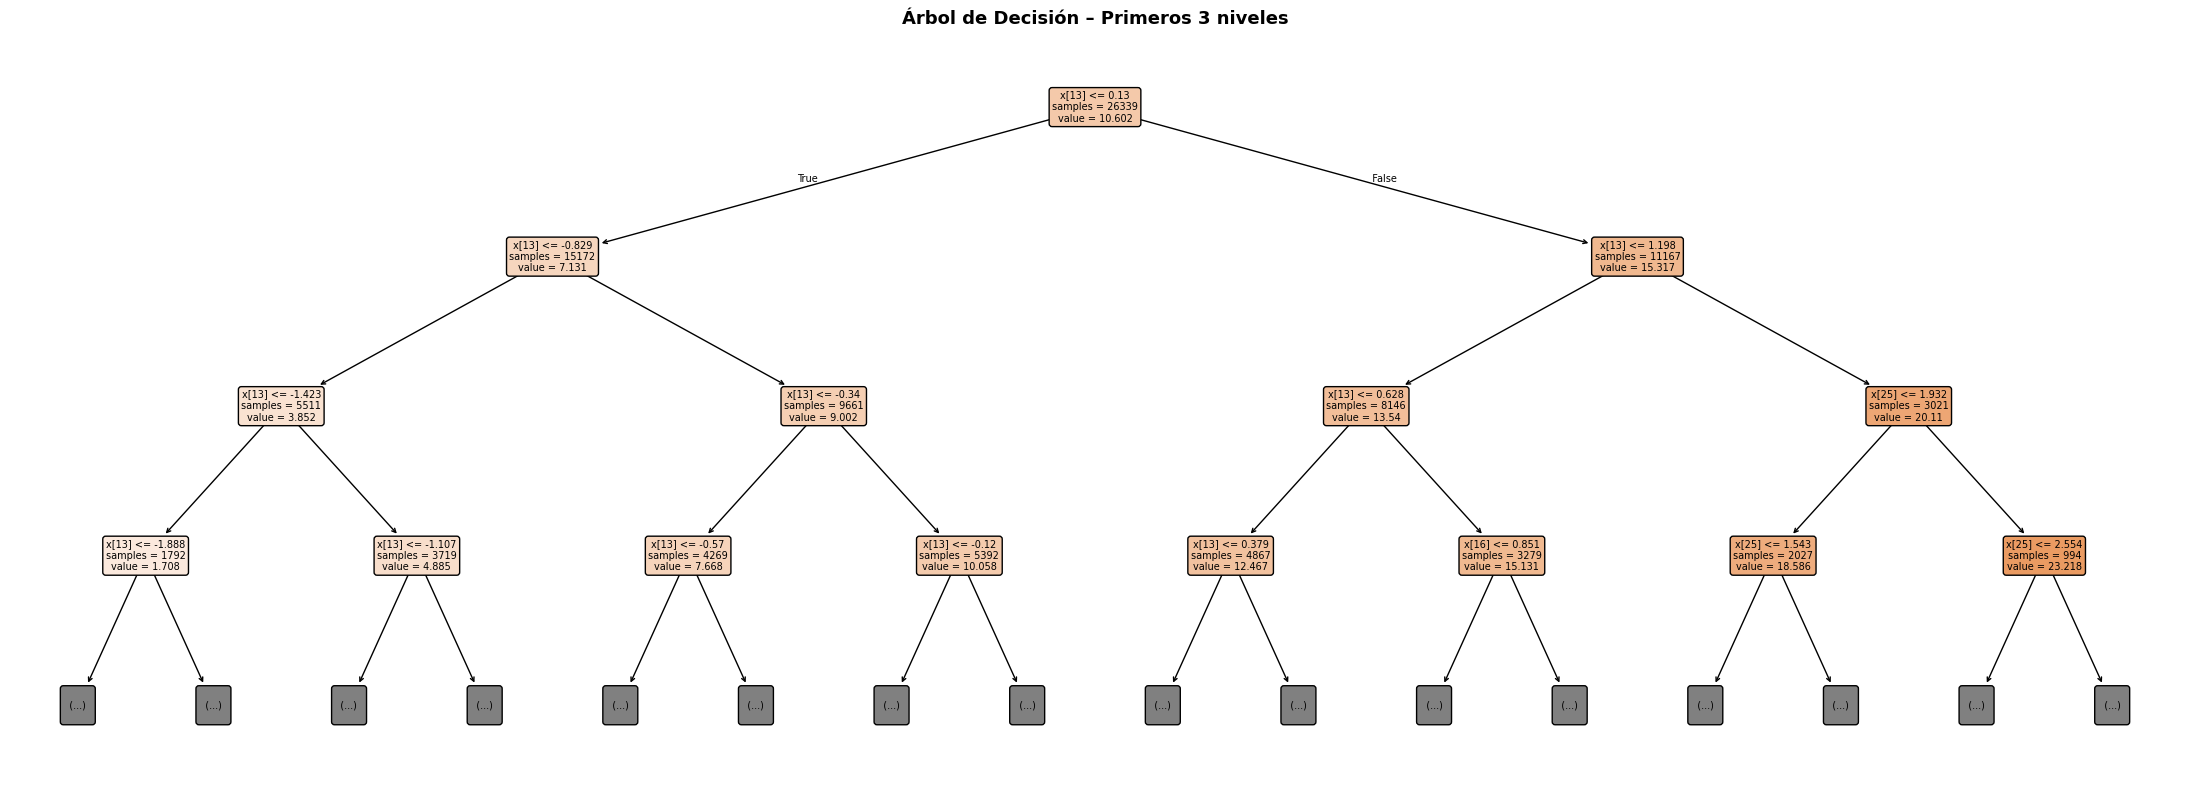

In [ ]:
# Visualización del árbol de decisión — primeros 3 niveles
plt.figure(figsize=(22, 8))
plot_tree(
    pipeline_dtr.named_steps['modelo'],
    max_depth=3,
    filled=True,
    fontsize=7,
    rounded=True,
    impurity=False
)
plt.title('Árbol de Decisión – Primeros 3 niveles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación:** Los modelos fueron evaluados mediante R² y MAE en entrenamiento y prueba. El modelo `LinearRegression` alcanza un R² superior al 95% y un MAE igual o inferior a 0.38, con diferencia mínima entre entrenamiento y prueba, lo que indica que no presenta overfitting. El `DecisionTreeRegressor` también presenta buen nivel de explicación según R², capturando relaciones no lineales entre las variables.

## 17. Predicción de una Nueva Observación

Se selecciona una observación del conjunto de prueba para comparar las predicciones de ambos modelos con el valor real.

In [ ]:
nueva_observacion = X_test.iloc[[0]]

pred_lr  = pipeline_lr.predict(nueva_observacion)[0]
pred_dtr = pipeline_dtr.predict(nueva_observacion)[0]
valor_real = y_test.iloc[0]

print(f'Predicción LinearRegression      : {pred_lr:.2f}°C')
print(f'Predicción DecisionTreeRegressor : {pred_dtr:.2f}°C')
print(f'Valor real                       : {valor_real:.2f}°C')

Predicción LinearRegression      : 3.69°C
Predicción DecisionTreeRegressor : 3.92°C
Valor real                       : 3.55°C


## 18. Tabla Resumen de Modelos

In [ ]:
r2_lr_train  = pipeline_lr.score(X_train, y_train)
r2_lr_test   = r2_score(y_test, y_pred_lr)
mae_lr       = mean_absolute_error(y_test, y_pred_lr)

r2_dtr_train = pipeline_dtr.score(X_train, y_train)
r2_dtr_test  = r2_score(y_test, y_pred_dtr)
mae_dtr      = mean_absolute_error(y_test, y_pred_dtr)

def condicion(train, test):
    if abs(train - test) > 0.05:
        return 'Posible Overfitting'
    return 'Sin overfitting'

resumen = pd.DataFrame({
    'Modelo':               ['LinearRegression', 'DecisionTreeRegressor'],
    'R² entrenamiento':     [f'{r2_lr_train:.4f}',  f'{r2_dtr_train:.4f}'],
    'R² prueba':            [f'{r2_lr_test:.4f}',   f'{r2_dtr_test:.4f}'],
    'MAE':                  [f'{mae_lr:.4f}',        f'{mae_dtr:.4f}'],
    'Condición':            [condicion(r2_lr_train, r2_lr_test), condicion(r2_dtr_train, r2_dtr_test)],
    'Predicción nueva obs.':[f'{pred_lr:.2f}°C',     f'{pred_dtr:.2f}°C']
})
resumen

,Modelo,R² entrenamiento,R² prueba,MAE,Condición,Predicción nueva obs.
0,LinearRegression,0.9906,0.9905,0.3714,Sin overfitting,3.69°C
1,DecisionTreeRegressor,0.9919,0.9860,0.4420,Sin overfitting,3.92°C


## 19. Casos de Uso de Cada Modelo

**Regresión Lineal (`LinearRegression`):**  
Es el modelo principal para este problema. Presenta el menor MAE en el conjunto de prueba, un R² superior al 95% y una diferencia mínima entre entrenamiento y prueba, lo que indica buen equilibrio entre capacidad predictiva y generalización. Se recomienda en contextos donde se necesita predecir la temperatura con alta precisión y explicar el comportamiento a tomadores de decisión.

**Árbol de Decisión (`DecisionTreeRegressor`):**  
Se recomienda como modelo complementario cuando se requiera interpretar reglas de decisión o analizar relaciones no lineales entre las variables climáticas y la temperatura. Es útil para generar alertas tempranas de heladas basadas en condiciones específicas del clima. Sin embargo, su MAE es mayor que el de la regresión lineal, por lo que no se selecciona como modelo principal.

---
## 20. Comparación de Modelos – Configuraciones Alternativas

Se construyen versiones alternativas de cada modelo con diferentes
configuraciones para demostrar el impacto de los hiperparámetros
y la selección de variables en el rendimiento final.

In [ ]:
# ── Modelo 1B: LinearRegression sin lags ni ventanas ──────────────────
features_lr_simple = [
    'relative_humidity_2m', 'precipitation', 'cloud_cover',
    'wind_speed_10m', 'wind_direction_10m', 'rain', 'sunshine_duration',
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
    'latitud', 'longitud'
]
features_cat_simple = ['Localidad', 'is_day', 'is_rainy_hour']

preprocessor_simple = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ]), features_lr_simple),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), features_cat_simple)
], remainder='drop')

X_simple = data[features_lr_simple + features_cat_simple]
X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)

pipeline_lr_simple = Pipeline(steps=[
    ('preprocesamiento', preprocessor_simple),
    ('colinealidad',     CorrelationFilter(threshold=0.9)),
    ('modelo',           LinearRegression())
])

# ── Modelo 2B: DecisionTree con max_depth=3 ────────────────────────────
pipeline_dtr_simple = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('modelo',           DecisionTreeRegressor(
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

pipeline_lr_simple.fit(X_simple_train, y_simple_train)
pipeline_dtr_simple.fit(X_train, y_train)

print('Modelos alternativos entrenados correctamente')

Modelos alternativos entrenados correctamente


In [ ]:
y_pred_lr_simple  = pipeline_lr_simple.predict(X_simple_test)
y_pred_dtr_simple = pipeline_dtr_simple.predict(X_test)

r2_lr_s_train  = pipeline_lr_simple.score(X_simple_train, y_simple_train)
r2_lr_s_test   = r2_score(y_simple_test, y_pred_lr_simple)
mae_lr_s       = mean_absolute_error(y_simple_test, y_pred_lr_simple)

r2_dtr_s_train = pipeline_dtr_simple.score(X_train, y_train)
r2_dtr_s_test  = r2_score(y_test, y_pred_dtr_simple)
mae_dtr_s      = mean_absolute_error(y_test, y_pred_dtr_simple)

comparacion = pd.DataFrame({
    'Modelo': [
        'LinearRegression (completo)',
        'LinearRegression (sin lags)',
        'DecisionTreeRegressor (max_depth=10)',
        'DecisionTreeRegressor (max_depth=3)'
    ],
    'R² Train': [
        f'{r2_lr_train:.4f}',  f'{r2_lr_s_train:.4f}',
        f'{r2_dtr_train:.4f}', f'{r2_dtr_s_train:.4f}'
    ],
    'R² Test': [
        f'{r2_lr_test:.4f}',  f'{r2_lr_s_test:.4f}',
        f'{r2_dtr_test:.4f}', f'{r2_dtr_s_test:.4f}'
    ],
    'MAE Test': [
        f'{mae_lr:.4f}',  f'{mae_lr_s:.4f}',
        f'{mae_dtr:.4f}', f'{mae_dtr_s:.4f}'
    ],
    'Condición': [
        condicion(r2_lr_train,  r2_lr_test),
        condicion(r2_lr_s_train, r2_lr_s_test),
        condicion(r2_dtr_train, r2_dtr_test),
        condicion(r2_dtr_s_train, r2_dtr_s_test)
    ]
})
comparacion

,Modelo,R² Train,R² Test,MAE Test,Condición
0,LinearRegression (completo),0.9906,0.9905,0.3714,Sin overfitting
1,LinearRegression (sin lags),0.8038,0.8046,1.7918,Sin overfitting
2,DecisionTreeRegressor (max_depth=10),0.9919,0.9860,0.4420,Sin overfitting
3,DecisionTreeRegressor (max_depth=3),0.9377,0.9327,1.0441,Sin overfitting


**Interpretación:**

La tabla de comparación demuestra el impacto de la ingeniería de
características y los hiperparámetros:

- **LinearRegression sin lags:** sin los rezagos y ventanas móviles,
  el MAE sube de 0.37°C a 1.79°C — casi 5 veces más error. Esto confirma
  que los lags son la variable más importante del modelo.

- **DecisionTreeRegressor max_depth=3:** al limitar la profundidad a 3
  niveles, el R² baja de 0.986 a 0.933 y el MAE sube a 1.04°C. El árbol
  no tiene capacidad suficiente para capturar la complejidad climática.

El modelo seleccionado como principal es **LinearRegression completo**,
por su menor MAE (0.37°C), R² superior al 99% y ausencia de overfitting.